In [ ]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import modularity
from community import community_louvain 



In [27]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usenames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [28]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [29]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [30]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth'))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)

    return df_data, republican_df, democratic_df

In [31]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [32]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [33]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [ ]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    mod_value = modularity(G, communities)


    return communities, mod_value

In [35]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politcian
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [36]:
def visualise_graph(G, communities, spacing, title):

    """ Visualise graph coloured red and blue for R and D classed by louvain algorithm respectively """
    
    community1 = communities[0]
    plt.figure(figsize=(20, 15))
    node_colors = []
    for node in G.nodes():
        if node in community1:
            node_colors.append('red')
        else:
            node_colors.append('lightskyblue')

    pos = nx.spring_layout(G, k=spacing/np.sqrt(len(G.nodes())), iterations=20)
    nx.draw(
        G, pos=pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=6
    )
    plt.title(title, fontsize=16)
    plt.show()
    

In [37]:
df_data, republican_df, democratic_df = read_data(-1)
G_bipartite = build_bipartite_network(df_data)
degree_lower_2_remover(df_data, G_bipartite)

In [43]:
threshold_value = 26
G = build_network(df_data, threshold_value, False, True)

In [44]:
# Create communities based on the 'party' attribute in df_data (based on ground truth)
communities = []
parties = df_data['party'].unique()

for party in parties:
    nodes_in_party = df_data[df_data['party'] == party]['current_twitter_name'].tolist()
    communities.append(nodes_in_party)

# Convert list of communities to list of sets for modularity calculation
community_sets = [set(community) for community in communities]

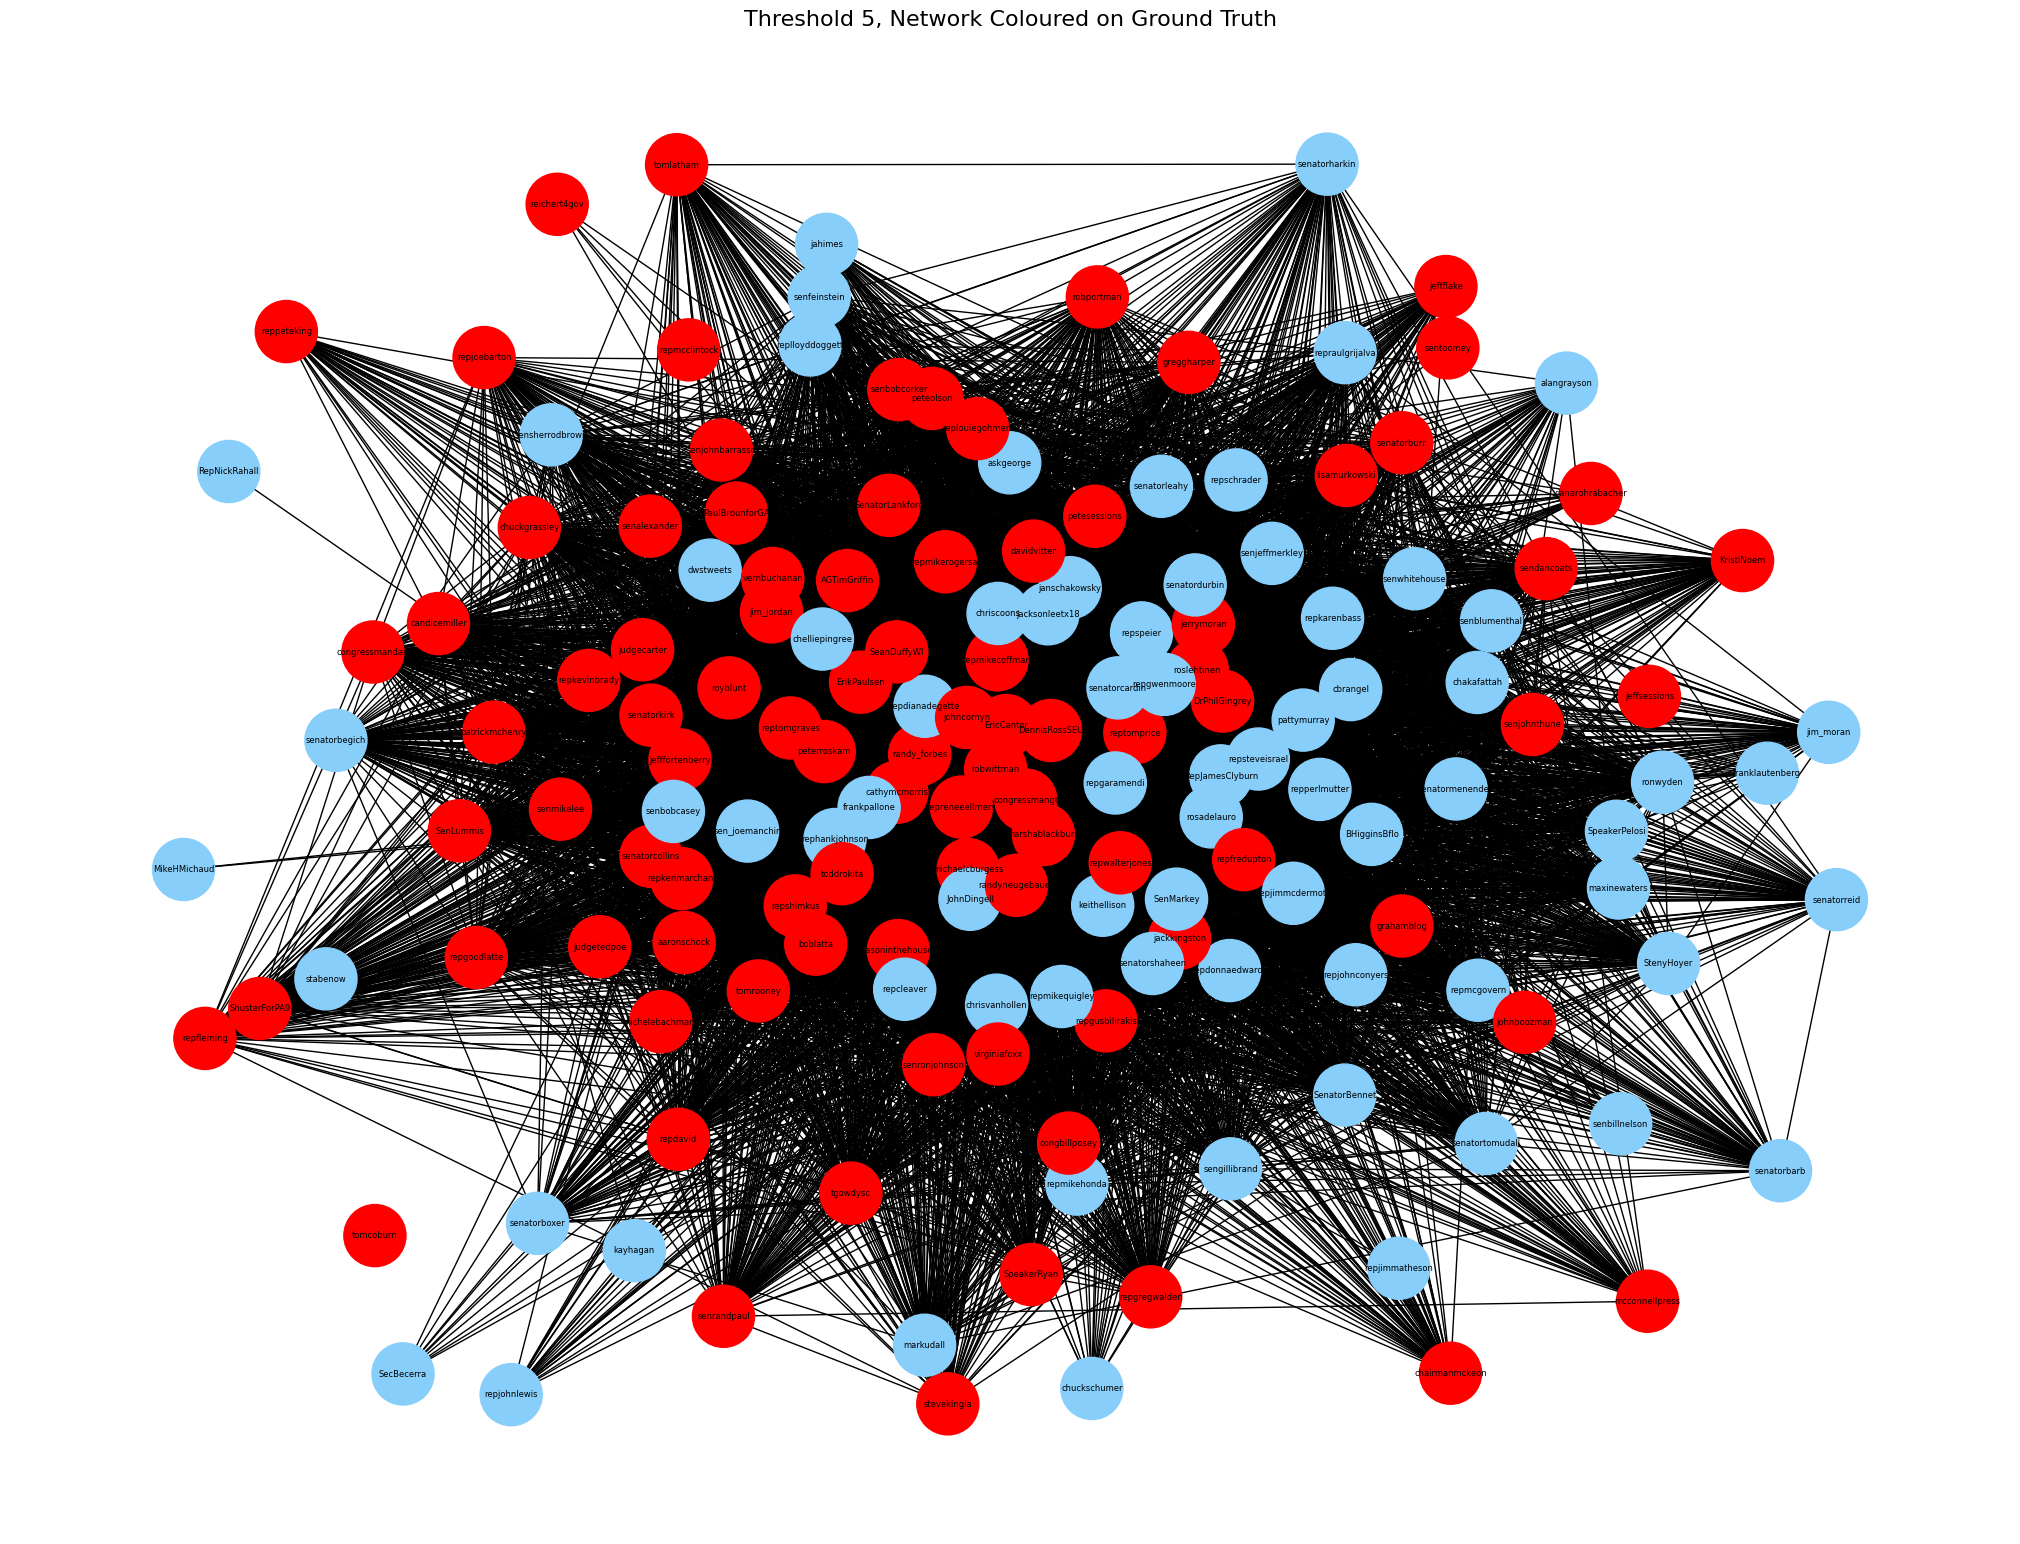

In [46]:
title = "Threshold 5, Network Coloured on Ground Truth"
visualise_graph(G, community_sets, 65, title)

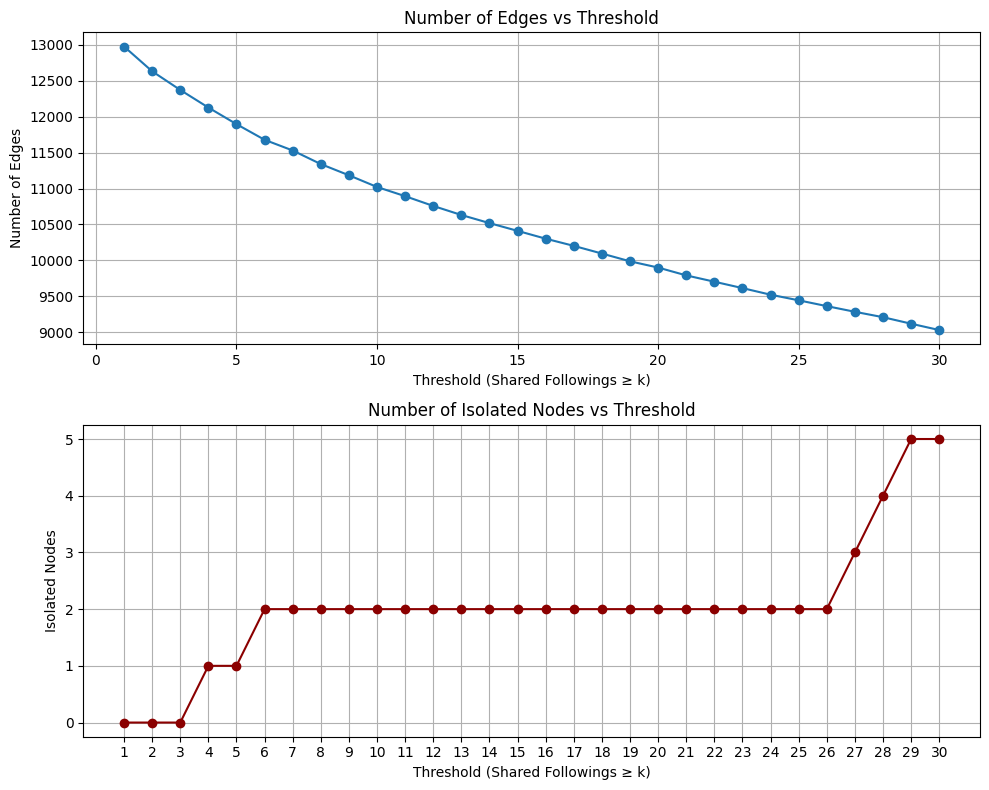

In [41]:
df_data, _, _ = read_data(-1)

thresholds = list(range(1, 31))
edge_counts = []
isolated_counts = []

for k in thresholds:
    G = build_network(df_data, k, hits=False, weighted=False)
    edge_counts.append(G.number_of_edges())

    # Count isolated nodes
    isolated = [node for node, degree in dict(G.degree()).items() if degree == 0]
    isolated_counts.append(len(isolated))

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Edge Count Plot
axs[0].plot(thresholds, edge_counts, marker='o')
axs[0].set_title("Number of Edges vs Threshold")
axs[0].set_xlabel("Threshold (Shared Followings ≥ k)")
axs[0].set_ylabel("Number of Edges")
axs[0].grid(True)

# Isolated Node Count Plot
axs[1].plot(thresholds, isolated_counts, marker='o', color='darkred')
axs[1].set_title("Number of Isolated Nodes vs Threshold")
axs[1].set_xlabel("Threshold (Shared Followings ≥ k)")
axs[1].set_ylabel("Isolated Nodes")
axs[1].grid(True)

plt.xticks(thresholds)
plt.tight_layout()
plt.show()


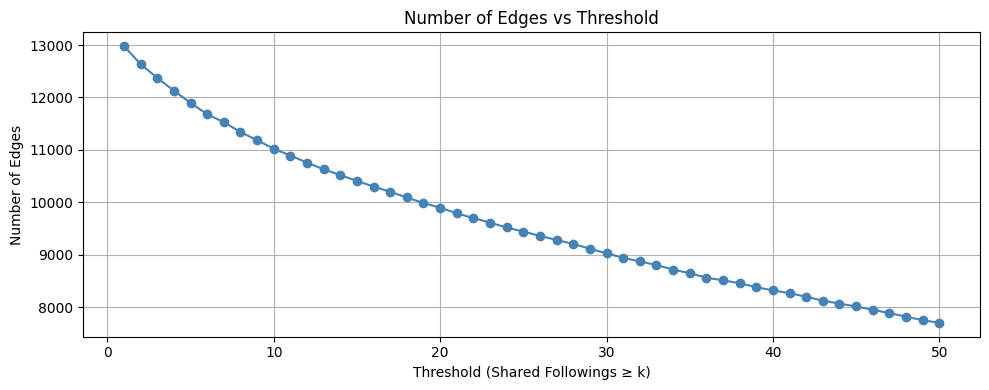

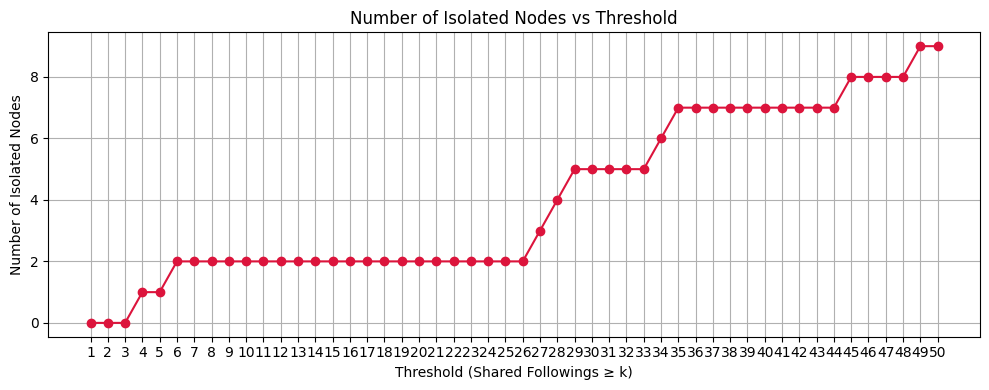

In [47]:
df_data, _, _ = read_data()

thresholds = list(range(1, 51))
edge_counts = []
isolated_counts = []

for k in thresholds:
    G = build_network(df_data, k, hits=False, weighted=False)
    edge_counts.append(G.number_of_edges())

    isolated = [node for node, degree in dict(G.degree()).items() if degree == 0]
    isolated_counts.append(len(isolated))

# --- Plot 1: Number of Edges ---
plt.figure(figsize=(10, 4))
plt.plot(thresholds, edge_counts, marker='o', color='steelblue')
plt.title("Number of Edges vs Threshold")
plt.xlabel("Threshold (Shared Followings ≥ k)")
plt.ylabel("Number of Edges")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Number of Isolated Nodes ---
plt.figure(figsize=(10, 4))
plt.plot(thresholds, isolated_counts, marker='o', color='crimson')
plt.title("Number of Isolated Nodes vs Threshold")
plt.xlabel("Threshold (Shared Followings ≥ k)")
plt.ylabel("Number of Isolated Nodes")
plt.grid(True)
plt.xticks(range(1, 51, 2))
plt.yticks(range(1, max(isolated_counts) + 1))
plt.tight_layout()
plt.show()


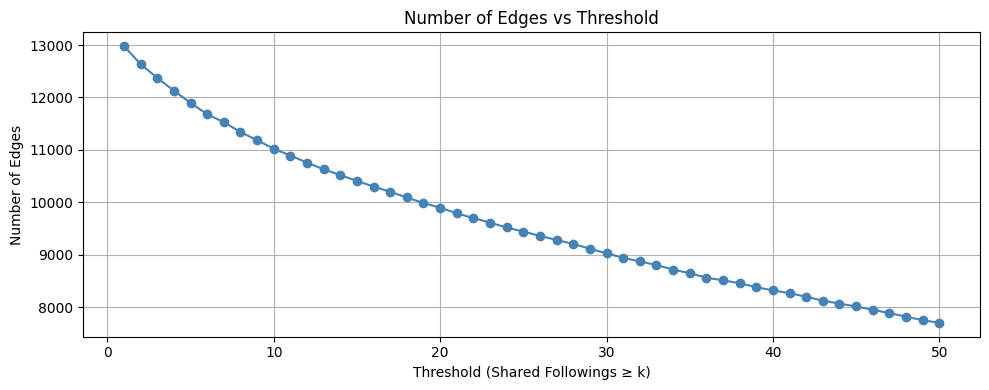

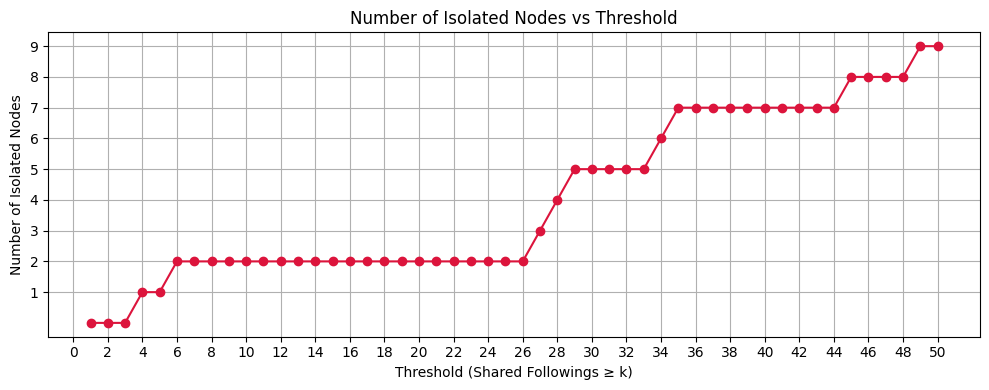

In [49]:
# --- Plot 1: Number of Edges ---
plt.figure(figsize=(10, 4))
plt.plot(thresholds, edge_counts, marker='o', color='steelblue')
plt.title("Number of Edges vs Threshold")
plt.xlabel("Threshold (Shared Followings ≥ k)")
plt.ylabel("Number of Edges")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Number of Isolated Nodes ---
plt.figure(figsize=(10, 4))
plt.plot(thresholds, isolated_counts, marker='o', color='crimson')
plt.title("Number of Isolated Nodes vs Threshold")
plt.xlabel("Threshold (Shared Followings ≥ k)")
plt.ylabel("Number of Isolated Nodes")
plt.grid(True)
plt.xticks(range(0, 51, 2))
plt.yticks(range(1, max(isolated_counts) + 1))
plt.tight_layout()
plt.show()

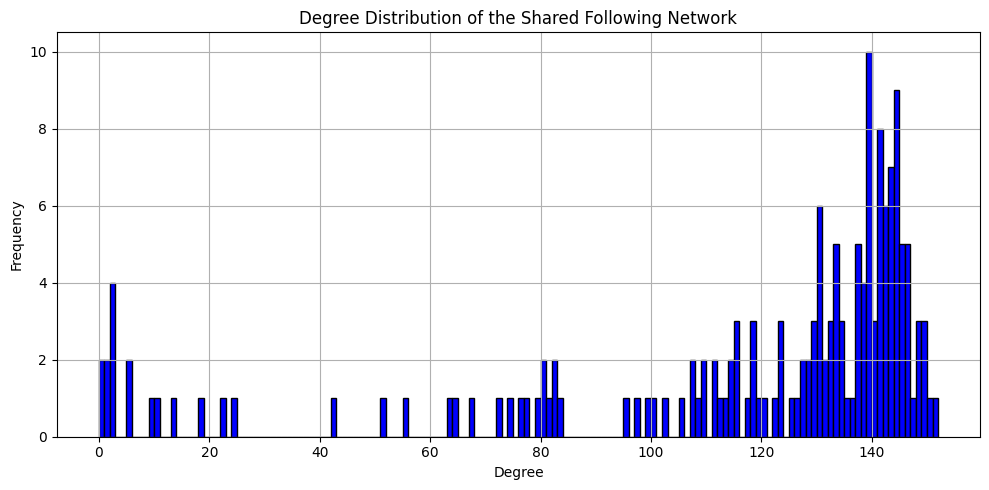

In [52]:
def plot_degree_distribution(G):
    degrees = [d for n, d in G.degree()]
    
    plt.figure(figsize=(10, 5))
    plt.hist(degrees, bins=range(min(degrees), max(degrees) + 1), color='blue', edgecolor='black')
    plt.title("Degree Distribution of the Shared Following Network")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
G = build_network(df_data, 26, hits=False, weighted=True)
plot_degree_distribution(G)
